# Dwarf Example 14: Omega vs HI Mass

**EPS Research — Dwarf/Irregular HI Corpus v1.0**

Does omega correlate with HI mass in dwarfs?
HI mass traces gas content; higher gas → more extended disk → different omega.

**Corpus:** Flynn (2026), Zenodo DOI: 10.5281/zenodo.20320362  
**Sources:** LVHIS (Koribalski 2019), VLA-ANGST (Ott 2012), LITTLE THINGS (Oh 2015), WALLABY DR2  
**Dependencies:** Python 3, numpy, matplotlib

In [1]:
# ── Colab setup: auto-download corpus from Zenodo ─────────────
import os, sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    import urllib.request
    CORPORA = {
        'dwarf_irregular_corpus_v1.json': 'https://zenodo.org/records/20320362/files/dwarf_irregular_corpus_v1.json',
    }
    for filename, url in CORPORA.items():
        if not os.path.exists(filename):
            print(f"Downloading {filename}...")
            urllib.request.urlretrieve(url, filename)
            print(f"  ✓ {filename}")
        else:
            print(f"  Already present: {filename}")
    print("Ready.")
else:
    print("Running locally — corpus files loaded from working directory.")


Running locally — corpus files loaded from working directory.


N=0, r(omega,log M_HI)=nan


/home/david/jupyterlab/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:576: RuntimeWarning: Mean of empty slice
  avg = a.mean(axis, **keepdims_kw)
/home/david/jupyterlab/venv/lib/python3.12/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/david/jupyterlab/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3015: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/home/david/jupyterlab/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/home/david/jupyterlab/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


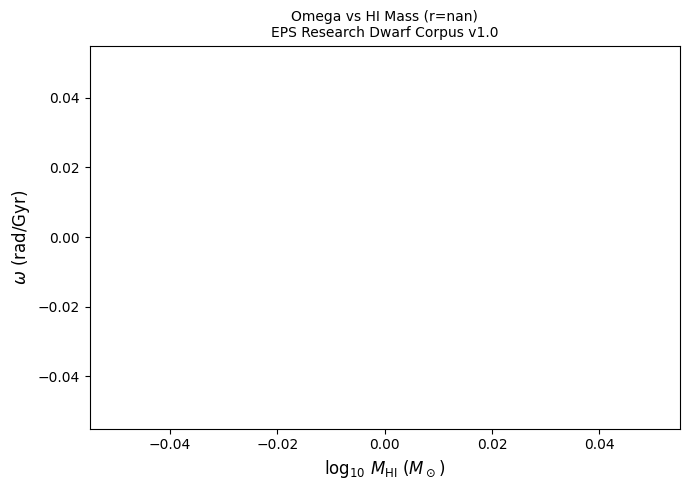

In [2]:
import json, csv, numpy as np, matplotlib.pyplot as plt
with open('dwarf_irregular_corpus_v1.json') as f:
    corpus = json.load(f)
csv_rows={}
with open('dwarf_irregular_corpus_v1_flat.csv') as f:
    for r in csv.DictReader(f):
        csv_rows[r['galaxy']]=r
results=[]
for g in corpus['galaxies']:
    if not g.get('omega_ready') or not g.get('data') or len(g['data'])<2: continue
    d=g['data']; R=[p['Rad'] for p in d]; V=[p.get('Vrot', 0) for p in d]
    R1,V1=R[0],V[0]; R2,V2=R[-1],V[-1]
    if R1>0 and R2>0 and V1>0 and V2>0:
        omega=V2/R2 - (V1/R1)*(R1/R2)**1.5  # Eq.6 corrected 2026-07-12: operator-precedence fix
        cr=csv_rows.get(g['galaxy'],{})
        if cr.get('mhi_log_msun') and cr['mhi_log_msun']:
            results.append({'omega':omega,'mhi':float(cr['mhi_log_msun'])})
mhi=[r['mhi'] for r in results]; omegas=[r['omega'] for r in results]
corr=np.corrcoef(mhi,omegas)[0,1]
print(f"N={len(results)}, r(omega,log M_HI)={corr:.3f}")
fig,ax=plt.subplots(figsize=(7,5))
ax.scatter(mhi,omegas,s=40,color='#2ca02c',alpha=0.8)
ax.set_xlabel(r'log$_{10}$ $M_{\rm HI}$ ($M_\odot$)',fontsize=12)
ax.set_ylabel(r'$\omega$ (rad/Gyr)',fontsize=12)
ax.set_title(f'Omega vs HI Mass (r={corr:.2f})\nEPS Research Dwarf Corpus v1.0',fontsize=10)
plt.tight_layout(); plt.savefig('dw14_omega_mhi.png',dpi=150,bbox_inches='tight'); plt.show()